In [145]:
import io
import re
import base64
import time
import easyocr
import numpy as np
from PIL import Image
from openai import OpenAI
from ie_course.ocr import group_into_lines, lines_to_markdown
reader = easyocr.Reader(['en'])

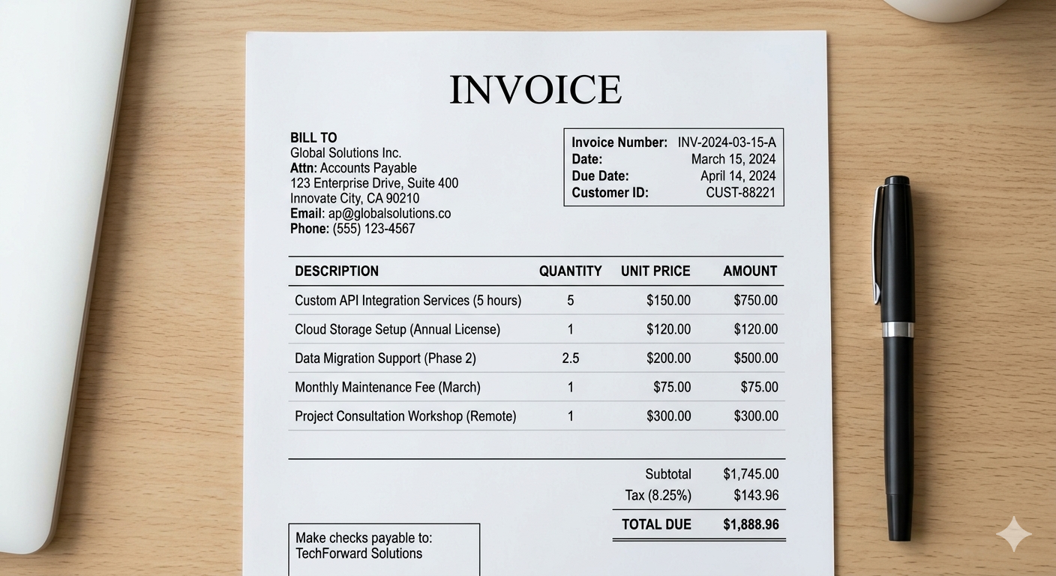

In [146]:
img = Image.open("../../data/gemini_generated_invoice.png")
img_small = img.resize((int(x * 0.75) for x in img.size))
img_small

# Classical IE (OCR and Regex)

In [147]:
img_np = np.array(img)
results = reader.readtext(img_np)
lines = group_into_lines(results, y_threshold=12)
markdown = lines_to_markdown(lines).lower()

/Users/luttmann/Documents/Lectures/ie/repos/ie_course_material/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [148]:
start = time.perf_counter()

matches = re.search(r"total\s+due\s+([s$]?\s?\d{1,3}(?:,\d{3})*(?:\.\d{2}))", markdown)

end = time.perf_counter()

regex_time = end - start

print(matches.group(1).strip("s").strip("$"))

1,888.96


# LLM-based IE

In [149]:
# NOTE this wont work on your machine, except you run an LLM on port 8000. 
client = OpenAI(base_url="http://localhost:8000/v1")
model_id = [x.id for x in client.models.list().data][0]

In [150]:
def pil_to_data_url(pil_img):
    buffer = io.BytesIO()
    pil_img.save(buffer, format="PNG")
    base64_image = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{base64_image}"
    
img_url = pil_to_data_url(img)

In [151]:
start = time.perf_counter()

response = client.chat.completions.create(
    model=model_id,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "Extract ONLY the total amount due from this invoice. Return only the number."
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": img_url
                    }
                }
            ]
        }
    ]
)
end = time.perf_counter()

llm_time = end - start

print(response.choices[0].message.content)

1,888.96


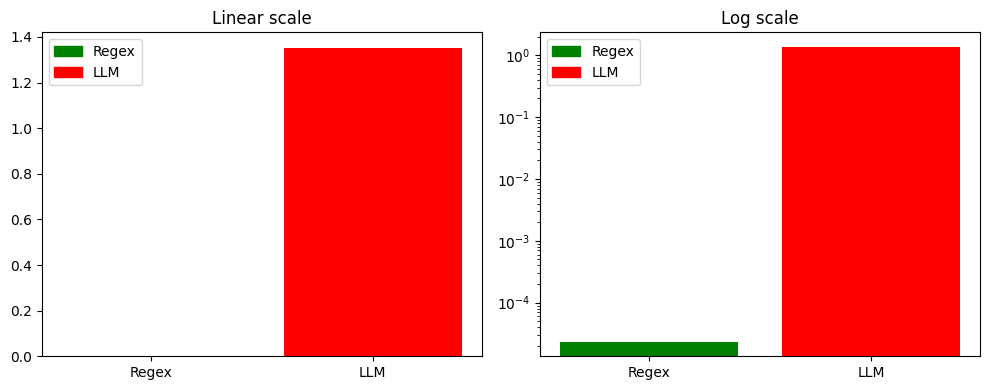

In [152]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

colors = ['green', 'red']

# --- Linear ---
axes[0].bar([0, 1], [regex_time, llm_time], color=colors)
axes[0].set_title("Linear scale")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Regex", "LLM"])

# --- Log ---
axes[1].bar([0, 1], [regex_time, llm_time], color=colors)
axes[1].set_yscale('log')
axes[1].set_title("Log scale")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Regex", "LLM"])

# --- shared legend (IMPORTANT FIX) ---
legend_handles = [
    Patch(color='green', label='Regex'),
    Patch(color='red', label='LLM')
]

axes[0].legend(handles=legend_handles)
axes[1].legend(handles=legend_handles)

plt.tight_layout()
plt.show()